In [249]:
"""
比较Open-pFind和Open-pFind+DL模式。
    收集修饰数目>=thr且error_cnt>0的修饰(并集)，联合绘制雷达图(echarts)
    https://echarts.apache.org/examples/zh/editor.html?c=radar&lang=ts
    https://echarts.apache.org/examples/zh/editor.html?c=pie-roseType-simple
"""

'\n比较pFind和+DL模式。\n'

In [217]:
"""
统计鉴定结果中的陷阱库肽段
threshold = 0.0044
"""
import os

res_dir = "D:/pFindWorkspace/normal/Gygi_2015_NBT/restrict-new/result/open-0628"
res_path = os.path.join(res_dir, "pFind-Filtered.spectra")

peptides = set()
mod2cnt = dict()
mod2error = dict()  # 存在该类型修饰的肽段中，decoy、陷阱库肽段数目
f = open(res_path,"r")
next(f,None)
for line in f:
    items = line.strip().split("\t")
    seq = items[5]
    mods = items[10]
    peptide  = seq + "\t" + mods
    is_decoy = (items[15]=="decoy")

    proteins = items[12].strip("/").split("/")
    flag = True
    for protein in proteins:
        if not protein.endswith("_ARATH"):
            flag = False
            break

    if peptide not in peptides:
        if mods == "":
            continue
        visit = set()  # 每个肽段出现多个同种修饰，只算作一次
        for pos_mod in mods.strip(";").split(";"):
            _,mod = pos_mod.split(",")
            if mod not in mod2cnt:
                mod2cnt[mod] = 1
            else:
                if mod not in visit:
                    mod2cnt[mod] += 1
            visit.add(mod)
        if flag:
            visit = set()  # 每个肽段出现多个同种修饰，只算作一次
            for pos_mod in mods.strip(";").split(";"):
                _,mod = pos_mod.split(",")
                if mod not in mod2error:
                    mod2error[mod] = 1
                else:
                    if mod not in visit:
                        mod2error[mod] += 1
                visit.add(mod)

    peptides.add(peptide)

In [ ]:
dl_mod2error = {'Oxidation[M]':0.003167940442719677,
    'Carbamidomethyl[C]':0.002061477850565761,
    'Gln->pyro-Glu[AnyN-termQ]':0.0006343165239454488,
    'Deamidated[N]':0.006276150627615063,
    'Unknown_302[AnyN-term]':0.00502828409805154,
    'AEBS[Y]':0.0006251953735542357,
    'Unknown_250[AnyN-term]':0.010309278350515464,
    'Carbamyl[AnyN-term]':0.0019602352282273874,
    'Acetyl[ProteinN-term]':0.003504300732717426,
    'Formyl[S](Ser->Asp[S])':0.0012219959266802445,
    'Dioxidation[W]':0.000574052812858783,
    'Cation_Fe[II][D]':0.0013531799729364006,
    'Unknown_302[D]':0.0019193857965451055,
    'Ammonia-loss[N]':0.002012072434607646,
    'Oxidation[W]':0.005208333333333333,
    'Carboxymethyl[AnyN-term]':0.011764705882352941,
    'Cation_Fe[II][E]':0.0016666666666666668,
    'Deamidated[Q]':0.0010857763300760044,
    'Unknown_302[E]':0.0028328611898017,
    'Carbamyl[K]':0.0004710315591144607,
    'Delta_H(6)C(3)O(1)[C]':0.006172839506172839,
    'Formyl[T](Thr->Glu[T])':0.0026690391459074734,
    'Iodo[Y]':0.003416856492027335,
    'Glu->Gln[E]':0.00404040404040404,
    'Carboxymethyl[C]':0.0013123359580052493,
    'Carbamidomethyl[AnyN-term]':0.004189944134078212,
    'Gln->Lys[Q]':0.005847953216374269,
    'Formyl[AnyN-term]':0.0035714285714285713,
    'Acetyl[AnyN-term]':0.005319148936170213,
    'Glu->pyro-Glu[AnyN-termE]':0.003605769230769231,
    'Dehydrated[D]':0.0022371364653243847,
    'Didehydro[S]':0.005747126436781609,
    'Ala->Asn[A]':0.002849002849002849,
    'Xle->Asn[L]':0.008849557522123894,
    'Succinyl[AnyN-term]':0.007220216606498195,
    'Cation_Ca[II][E]':0.006756756756756757,
    'Val->Thr[V]':0.03636363636363636,
    'Gly->Ala[G]':0.008849557522123894,
    'Didehydro[T]':0.016129032258064516,
    'Dethiomethyl[M]':0.005208333333333333,
    'Dehydrated[T]':0.007692307692307693,
    'C+12[AnyN-term]':0.015151515151515152,
    'Cation_Ca[II][D]':0.004878048780487805,
    'maleimide[C]':0.01639344262295082,
                
    'Carboxy[W]': 0.00,
    'Trp->Kynurenin[W]': 0.00,
    'Cation_Na[E]': 0.00,
    'Carbamidomethyl[M]': 0.00,
    'AEBS[K]': 0.00,
    'Arg-loss[AnyC-termR]': 0.06818181
}

labels = list()
dl_values = list()
values = list()
for dl_mod_name,dl_error_cnt in dl_mod2error.items():
    labels.append(dl_mod_name)
    dl_values.append(dl_error_cnt)
    cnt = mod2cnt[dl_mod_name]
    error_cnt = mod2error[dl_mod_name] if dl_mod_name in mod2error else 0
    values.append(error_cnt/cnt)
    print(dl_mod_name, error_cnt/cnt, dl_values[-1])
    
# print(values)
for value in values:
    if value == 0:
        print(0, end=',')
    else:
        print(f"{math.log(value*10000):.2f}", end=',')
        # print(f"{(value*10000):.2f}", end=',')
print(']')
for value in dl_values:
    if value == 0:
        print(0, end=',')
    else:
        print(f"{math.log(value*10000):.2f}", end=',')
        # print(f"{(value*10000):.2f}", end=',')
print(']')
for label,value in zip(labels,values):
    # print('{'+f"value:{math.log(value) if value!=0 else value},name:'{label}'"+'},')
    # print('{'+f"value:1 ,name:'{label}'"+'},')
    print('{'+f"name:'{label}', max: 6.5"+'},')

In [239]:
"""
统计鉴定结果中的decoy肽段
"""
import os

res_dir = "D:/pFindWorkspace/normal/Gygi_2015_NBT/restrict-new/result/open-0628"
res_path = os.path.join(res_dir, "pFind.spectra")

peptides = set()
mod2cnt = dict()
mod2error = dict()  # 存在该类型修饰的肽段中，decoy、陷阱库肽段数目
f = open(res_path,"r")
next(f,None)
for line in f:
    items = line.strip().split("\t")
    seq = items[5]
    mods = items[10]
    q_value = float(items[4])
    if q_value>0.01:
        break
    peptide  = seq + "\t" + mods
    is_decoy = (items[15]=="decoy")

    flag = False
    if is_decoy:
        flag = True

    # proteins = items[12].strip("/").split("/")
    # flag = True
    # for protein in proteins:
    #     if not protein.endswith("_ARATH"):
    #         flag = False
    #         break

    if peptide not in peptides:
        if mods == "":
            continue
        visit = set()  # 每个肽段出现多个同种修饰，只算作一次
        for pos_mod in mods.strip(";").split(";"):
            _,mod = pos_mod.split(",")
            if mod not in mod2cnt:
                mod2cnt[mod] = 1
            else:
                if mod not in visit:
                    mod2cnt[mod] += 1
            visit.add(mod)
        if flag:
            visit = set()  # 每个肽段出现多个同种修饰，只算作一次
            for pos_mod in mods.strip(";").split(";"):
                _,mod = pos_mod.split(",")
                if mod not in mod2error:
                    mod2error[mod] = 1
                else:
                    if mod not in visit:
                        mod2error[mod] += 1
                visit.add(mod)

    peptides.add(peptide)

Carbamidomethyl[C] 123 41732 0.29
Oxidation[M] 125 23410 0.53
Deamidated[N] 142 11119 1.28
Gln->pyro-Glu[AnyN-termQ] 31 6006 0.52
Deamidated[Q] 1 1623 0.06
Acetyl[ProteinN-term] 11 2819 0.39
AEBS[Y] 1 3126 0.03
Iodo[Y] 1 851 0.12
Carbamyl[AnyN-term] 22 12035 0.18
Unknown_302[AnyN-term] 1 1869 0.05
Arg-loss[AnyC-termR] 9 120 7.50
Formyl[S](Ser->Asp[S]) 2 2425 0.08
Cation_Fe[II][E] 1 1628 0.06
Oxidation[W] 1 730 0.14
Ammonia-loss[N] 1 486 0.21
Cation_Na[E] 1 188 0.53
Trp->Kynurenin[W] 1 279 0.36
Asp->Asn[D] 1 178 0.56
Didehydro[S] 1 129 0.78
Val->Pro[V] 1 205 0.49
Lys[AnyN-term] 1 361 0.28
Dehydrated[S] 8 102 7.84
Formyl[AnyN-term] 1 754 0.13
Carbamidomethyl[AnyN-term] 1 702 0.14
Dehydrated[D] 2 410 0.49
Dehydrated[T] 8 215 3.72
Glu->pyro-Glu[AnyN-termE] 1 754 0.13
Succinyl[AnyN-term] 1 180 0.56
28


In [247]:
dl_mod2error = {'Oxidation[M]':0.005630808001260041,
        'Carbamidomethyl[C]':0.00294607988672437,
        'Gln->pyro-Glu[AnyN-termQ]':0.005989911727616645,
        'Deamidated[N]':0.014131846306622871,
        'Unknown_302[AnyN-term]':0.0025078369905956114,
        'AEBS[Y]':0.0006248047485160887,
        'Unknown_250[AnyN-term]':0.002570694087403599,
        'Carbamyl[AnyN-term]':0.0013051179267269508,
        'Acetyl[ProteinN-term]':0.008214849921011059,
        'Pyro-carbamidomethyl[AnyN-termC]':0.0006844626967830253,
        'Formyl[S](Ser->Asp[S])':0.0016266775111834079,
        'Unknown_302[D]':0.0019157088122605363,
        'Ammonia-loss[N]':0.002008032128514056,
        'Lys[AnyN-term]':0.0024813895781637717,
        'Cation_Fe[II][E]':0.000555247084952804,
        'Phospho[S]':0.0009505703422053232,
        'Deamidated[Q]':0.0010845986984815619,
        'Unknown_302[E]':0.002824858757062147,
        'Formyl[T](Thr->Glu[T])':0.0008888888888888889,
        'Iodo[Y]':0.0022727272727272726,
        'Dehydrated[S]':0.0514018691588785,
        'Carbamidomethyl[AnyN-term]':0.001394700139470014,
        'Gln->Lys[Q]':0.005813953488372093,
        'Formyl[AnyN-term]':0.0011890606420927466,
        'Glu->pyro-Glu[AnyN-termE]':0.0012004801920768306,
        'Dehydrated[D]':0.002232142857142857,
        'Didehydro[S]':0.005714285714285714,
        'Cation_Na[D]':0.0072992700729927005,
        'Val->Pro[V]':0.0038022813688212928,
        'Succinyl[AnyN-term]':0.0035971223021582736,
        'Carbamyl[S]':0.0027247956403269754,
        'Cation_Na[E]':0.005813953488372093,
        'Val->Thr[V]':0.009009009009009009,
        'Dehydrated[T]':0.04411764705882353,
        'Trp->Kynurenin[W]':0.0037174721189591076,

        "Arg-loss[AnyC-termR]": 0.153846,
        "Oxidation[W]": 0.00,
        "Asp->Asn[D]": 0.00
}

# thr = 100
# names = set()
# k=0
# for mod_name, cnt in mod2cnt.items():
#     error_cnt = mod2error[mod_name] if mod_name in mod2error else 0
#     if cnt>thr and error_cnt!=0:
#         if mod_name not in dl_mod2error:
#             print(mod_name)

labels = list()
dl_values = list()
values = list()
for dl_mod_name,dl_error_cnt in dl_mod2error.items():
    labels.append(dl_mod_name)
    dl_values.append(dl_error_cnt)
    cnt = mod2cnt[dl_mod_name]
    error_cnt = mod2error[dl_mod_name] if dl_mod_name in mod2error else 0
    values.append(error_cnt/cnt)
    print(dl_mod_name, error_cnt/cnt, dl_values[-1])
    
# print(values)
for value in values:
    if value == 0:
        print(0, end=',')
    else:
        print(f"{math.log(value*10000):.2f}", end=',')
        # print(f"{(value*10000):.2f}", end=',')
print(']')
for value in dl_values:
    if value == 0:
        print(0, end=',')
    else:
        print(f"{math.log(value*10000):.2f}", end=',')
        # print(f"{(value*10000):.2f}", end=',')
print(']')
for label,value in zip(labels,values):
    # print('{'+f"value:{math.log(value) if value!=0 else value},name:'{label}'"+'},')
    print('{'+f"value:1 ,name:'{label}'"+'},')
    # print('{'+f"name:'', max: 7.5"+'},')

Oxidation[M] 0.005339598462195643 0.005630808001260041
Carbamidomethyl[C] 0.002947378510495543 0.00294607988672437
Gln->pyro-Glu[AnyN-termQ] 0.005161505161505162 0.005989911727616645
Deamidated[N] 0.012770932637827142 0.014131846306622871
Unknown_302[AnyN-term] 0.0005350454788657035 0.0025078369905956114
AEBS[Y] 0.0003198976327575176 0.0006248047485160887
Unknown_250[AnyN-term] 0.0 0.002570694087403599
Carbamyl[AnyN-term] 0.0018280016618196925 0.0013051179267269508
Acetyl[ProteinN-term] 0.0039020929407591345 0.008214849921011059
Pyro-carbamidomethyl[AnyN-termC] 0.0 0.0006844626967830253
Formyl[S](Ser->Asp[S]) 0.0008247422680412372 0.0016266775111834079
Unknown_302[D] 0.0 0.0019157088122605363
Ammonia-loss[N] 0.00205761316872428 0.002008032128514056
Lys[AnyN-term] 0.002770083102493075 0.0024813895781637717
Cation_Fe[II][E] 0.0006142506142506142 0.000555247084952804
Phospho[S] 0.0 0.0009505703422053232
Deamidated[Q] 0.0006161429451632779 0.0010845986984815619
Unknown_302[E] 0.0 0.0028248

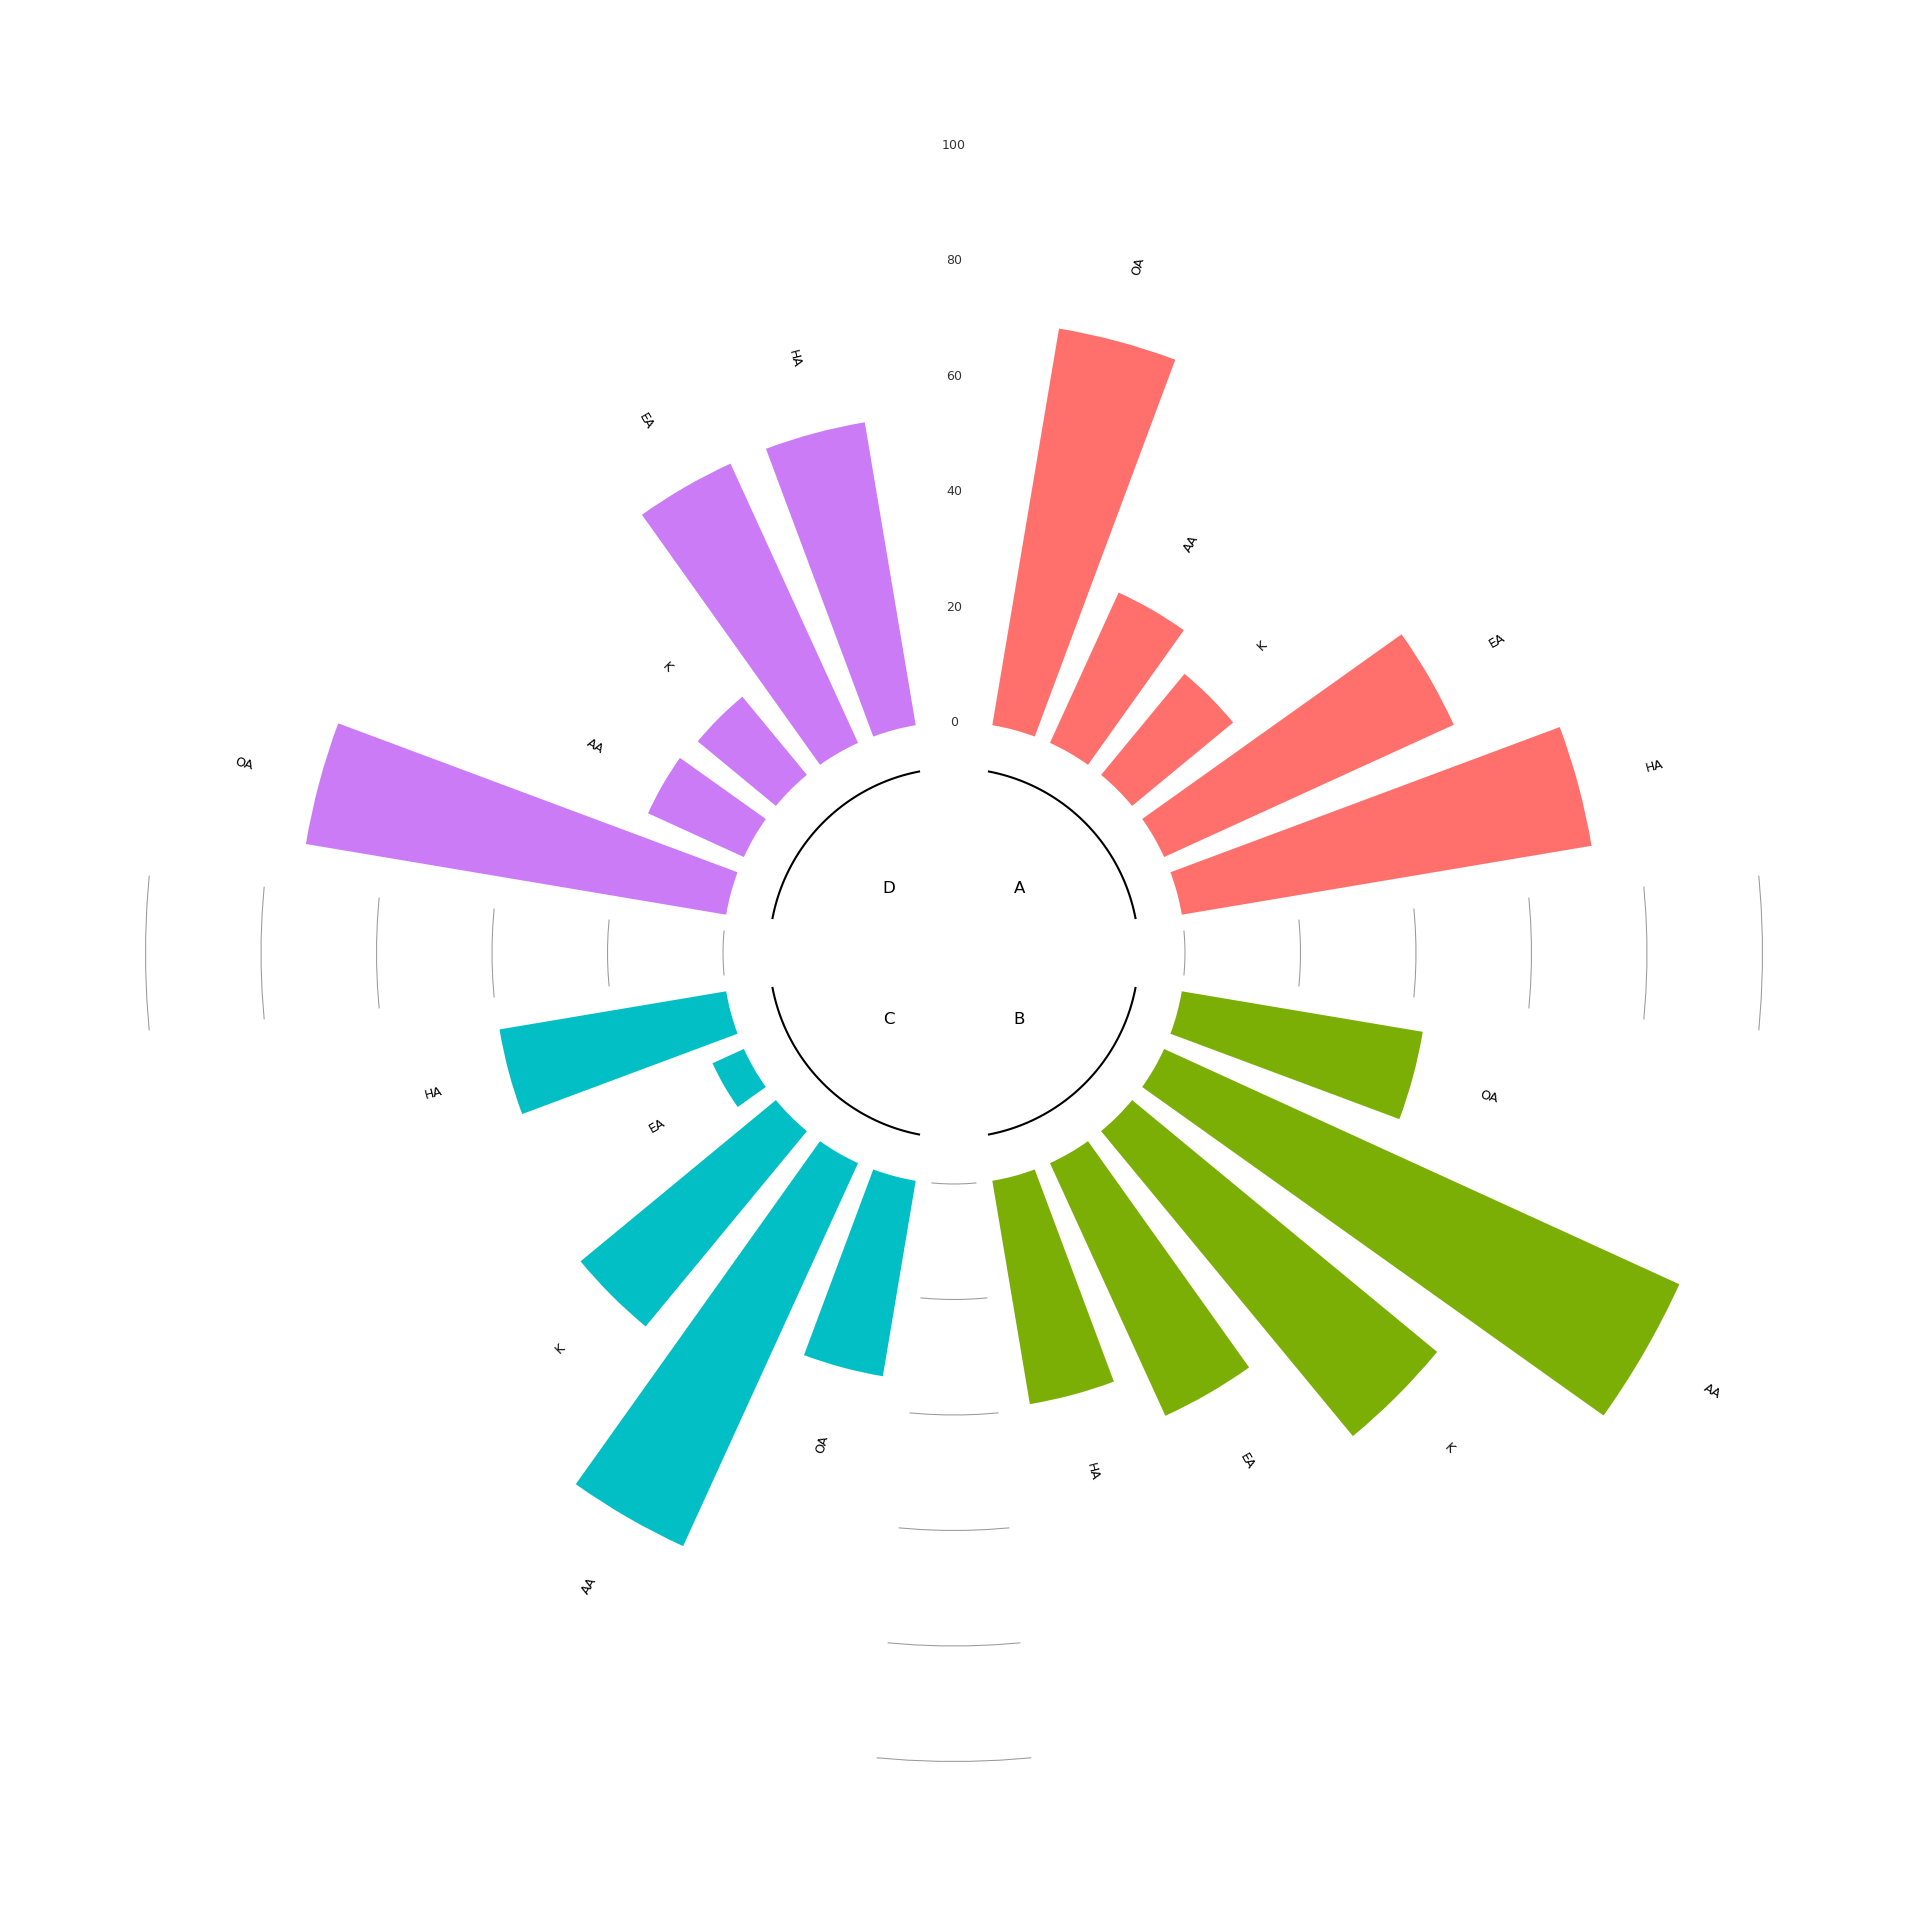

In [37]:
import matplotlib.pyplot as plt
import numpy as np
 
 
# 数据
np.random.seed(123)
group1 = 100 * np.random.rand(5)
group2 = 100 * np.random.rand(5)
group3 = 100 * np.random.rand(5)
group4 = 100 * np.random.rand(5)
 
groups = [group1, group2, group3, group4]
group_names = list('ABCD')
group_colors = ['#ff706d', '#7baf06', '#01bfc5', '#cb7bf6']
 
 
# 画图
fig = plt.figure(figsize=(8, 8), dpi=300, facecolor='white')
ax = fig.add_subplot(projection='polar')
 
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
 
radii = [0]
colors = ['white']
for g, c in zip(groups, group_colors):
    radii.extend(g)
    colors.extend([c]*len(g))
    radii.append(0)
    colors.append('white')
radii.pop()
colors.pop()
 
N = len(radii)
r_lim = 180
scale_lim = 100
scale_major = 20
bottom = 40
theta = np.linspace(0.0, 2 * np.pi, N, endpoint=False)
width = 2 * np.pi / (N + 9)
 
# 画出柱状图
ax.bar(theta, radii, width=width, bottom=bottom, color=colors)
 
# 画出刻度
def scale(ax, bottom, scale_lim, theta, width):
    t = np.linspace(theta-width/2, theta+width/2, 6)
    for i in range(int(bottom), int(bottom+scale_lim+scale_major), scale_major):
        ax.plot(t, [i]*6, linewidth=0.25, color='gray', alpha=0.8)
 
# 画出刻度值
def scale_value(ax, bottom, theta, scale_lim):
    for i in range(int(bottom), int(bottom+scale_lim+scale_major), scale_major):
        ax.text(theta,
                i,
                f'{i-bottom}',
                fontsize=3,
                alpha=0.8,
                va='center',
                ha='center'
                )
 
s_list = []
g_no = 0
aa = ["OA","AA","K","EA","HA"]
for t, r in zip(theta, radii):
    if r == 0:
        s_list.append(t)
        if t == 0:
            scale_value(ax, bottom, t, scale_lim)
        else:
            scale(ax, bottom, scale_lim, t, width)
    else:
        t2 = np.rad2deg(t)
        # 标出每根柱的名称
        ax.text(t, r + bottom + scale_major*0.6,
                aa[g_no],
                fontsize=3,
                rotation=90-t2 if t < np.pi else 270-t2,
                rotation_mode='anchor',
                va='center',
                ha='left' if t < np.pi else 'right',
                color='black',
                clip_on=False
                )
        if g_no == (len(aa)-1):
            g_no = 0
        else:
            g_no += 1
 
 
s_list.append(2 * np.pi)
 
for i in range(len(s_list)-1):
    t = np.linspace(s_list[i]+width, s_list[i+1]-width, 50)
    ax.plot(t, [bottom-scale_major*0.4]*50, linewidth=0.5, color='black')
    ax.text(s_list[i]+(s_list[i+1]-s_list[i])/2,
            bottom-scale_major*1.2,
            group_names[i],
            va='center',
            ha='center',
            fontsize=4,
            )
 
ax.set_rlim(0, bottom+scale_lim+scale_major)
ax.axis('off')
 
plt.show()

0.002066860534980413
0.0021043590294180805
0.004646078163432632
0.0013389121338912135
0.0006165228113440197
0.002492877492877493
0.00096
0.001176470588235294
0.0006031363088057901
0.002414051444268709
0.0016059957173447537
0.009174311926605505
0.0004514672686230248
0.05405405405405406
0.001417434443656981
0.0004127115146512588
0.0018438844499078057
0.0054869684499314125
0.008247422680412371
0.004739336492890996
0.0106951871657754
0.004545454545454545
0.007194244604316547
0.0078125
0.005681818181818182
0.003067484662576687
0.007462686567164179
0.0026560424966799467
0.015228426395939087
0.0028530670470756064
0.0014936519790888724
0.0015408320493066256
0.0013280212483399733


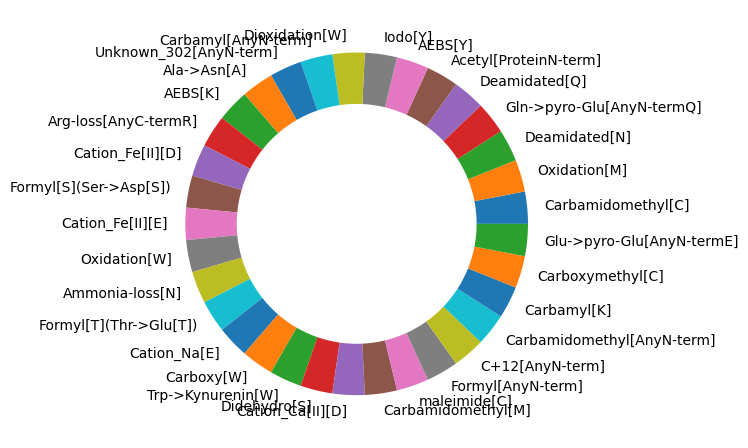

In [151]:
import matplotlib.pyplot as plt

thr = 100
labels = list()
values = list()
for mod_name, cnt in mod2cnt.items():
    error_cnt = mod2error[mod_name] if mod_name in mod2error else 0
    # print(mod_name, cnt, error_cnt)
    if cnt >= thr and error_cnt != 0:
        print(error_cnt/cnt)
        labels.append(mod_name)
        values.append(error_cnt/cnt*10000)

size_of_groups = [1]*len(labels)  # 各修饰的大小（决定弧长）

# 绘制圆环图并添加外侧标签
plt.pie(
    size_of_groups,
    labels=labels,          # 修饰名称
    labeldistance=1.1,      # 标签位置（>1 表示在圆环外侧）
    wedgeprops=dict(width=0.3)  # 控制圆环宽度（0.3表示环的厚度）
)

# 调整布局避免标签被截断
plt.tight_layout()
plt.show()